<h1 align="center"> Image Captioning (10 баллов) </h1>

В этом ноутбуке вы обучите сеть составлять подписи к изображениям.
![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные (0.5 балла)

In [1]:
# Скачайте датасет по ссылке https://drive.google.com/file/d/1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO/view?usp=sharing

In [2]:
%%time
# Read Dataset
import numpy as np
import json

img_codes = np.load("data/image_codes.npy")
captions = json.load(open('data/captions_tokenized.json'))

CPU times: total: 969 ms
Wall time: 1.57 s



Чтобы сэкономить ваше время, мы уже преобразовали все изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

Весь процесс занимает от одного дня на CPU до примерно 10 минут на трёх GPU Tesla M40. [Если хотите попробовать сделать это самостоятельно — пожалуйста.](https://gist.github.com/justheuristic/11fd01f9c12c0bf960499580d104130b).


In [3]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [4]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


Мы не хотим, чтобы сеть на каждом шаге предсказывала вероятности для миллиона слов, поэтому нужно немного сократить словарь.

Для этого посчитайте, **сколько раз встречается каждое слово** — так мы сможем решить, какие слова оставить в словаре.

In [5]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for caps in captions:
    for cap in caps:
        word_counts += Counter(cap)

In [6]:
word_counts

Counter({'a': 978125,
         '#START#': 591435,
         '#END#': 591435,
         '.': 444651,
         'on': 215537,
         'of': 203940,
         'the': 197668,
         'in': 183933,
         'with': 154705,
         'and': 140709,
         'is': 98138,
         'man': 72984,
         'to': 68106,
         'sitting': 52880,
         'an': 49848,
         'two': 48320,
         ',': 44448,
         'at': 42703,
         'standing': 42450,
         'people': 41895,
         'are': 41060,
         'next': 37196,
         'white': 36171,
         'woman': 33934,
         'street': 30253,
         'table': 30157,
         'holding': 27952,
         'that': 27920,
         'large': 24540,
         'it': 24528,
         'person': 24402,
         'some': 24314,
         'down': 23093,
         'top': 22262,
         'group': 21585,
         'up': 20964,
         'field': 20768,
         'small': 20074,
         'tennis': 19577,
         'near': 19558,
         'front': 19501,
         

In [7]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [8]:
word_to_index

{'#UNK#': 0,
 '#START#': 1,
 '#END#': 2,
 '#PAD#': 3,
 'people': 4,
 'shopping': 5,
 'in': 6,
 'an': 7,
 'open': 8,
 'market': 9,
 'for': 10,
 'vegetables': 11,
 '.': 12,
 'full': 13,
 'of': 14,
 'and': 15,
 'piles': 16,
 'are': 17,
 'at': 18,
 'air': 19,
 'produce': 20,
 'large': 21,
 'carrots': 22,
 'potatoes': 23,
 'a': 24,
 'crowded': 25,
 'outdoor': 26,
 'shop': 27,
 'like': 28,
 'person': 29,
 'skiing': 30,
 'down': 31,
 'steep': 32,
 'hill': 33,
 'snowy': 34,
 'on': 35,
 'snow': 36,
 'skis': 37,
 'going': 38,
 'slope': 39,
 'skier': 40,
 'is': 41,
 'shown': 42,
 'taking': 43,
 'very': 44,
 'the': 45,
 'black': 46,
 'white': 47,
 'dog': 48,
 'stands': 49,
 'near': 50,
 'holding': 51,
 'frisbee': 52,
 'looking': 53,
 'blue': 54,
 'watches': 55,
 'who': 56,
 'man': 57,
 'with': 58,
 'another': 59,
 'laying': 60,
 'couple': 61,
 'dogs': 62,
 'that': 63,
 'grassy': 64,
 'field': 65,
 'skateboarder': 66,
 'putting': 67,
 'show': 68,
 'using': 69,
 'picnic': 70,
 'table': 71,
 'as': 72

In [9]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [10]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети (1.5 балла)

Как уже упоминалось, мы создадим RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения мы будем использовать уже готовые вектора-признаков, а сеть Inception добавим на этапе инференса.


In [11]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [12]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        # a layer that converts conv features to
        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        # recurrent part, please create the layers as per scheme above.

        # create embedding for input words. Use the parameters (e.g. emb_size).
        self.emb = nn.Embedding(n_tokens, emb_size)

        # lstm: create a recurrent core of your network. Use either LSTMCell or just LSTM.
        # In the latter case (nn.LSTM), make sure batch_first=True
        self.lstm = nn.LSTM(emb_size, lstm_units, batch_first=True)

        # create logits: linear layer that takes lstm hidden state as input and computes one number per token
        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        # compute embeddings for captions_ix
        captions_emb = self.emb(captions_ix)

        # apply recurrent layer to captions_emb.
        # 1. initialize lstm state with initial_* from above
        # 2. feed it with captions. Mind the dimension order in docstring
        # 3. compute logits for next token probabilities
        # Note: if you used nn.LSTM, you can just give it (initial_cell[None], initial_hid[None]) as second arg

        # lstm_out should be lstm hidden state sequence of shape [batch, caption_length, lstm_units]
        lstm_out, (hn, cn) = self.lstm(captions_emb, (initial_cell[None], initial_hid[None]))

        # compute logits from lstm_out
        logits = self.logits(lstm_out)

        return logits

In [13]:
network = CaptionNet(n_tokens)

In [14]:
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [15]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """

    # captions for input - all except last cuz we don't know next token for last one.
    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    # apply the network, get predictions for captions_ix_next
    logits_for_next = network.forward(image_vectors, captions_ix_inp)


    # compute the loss function between logits_for_next and captions_ix_next
    # Use the mask, Luke: make sure that predicting next tokens after EOS do not contribute to loss
    # you can do that either by multiplying elementwise loss by (captions_ix_next != pad_ix)
    # or by using ignore_index in some losses.

    loss = nn.CrossEntropyLoss(ignore_index=pad_ix)(logits_for_next.view(-1, logits_for_next.shape[2]), captions_ix_next.view(-1))
    return loss

In [16]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([]), 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'


Добавьте ~~adam~~ ваш любимы оптимизатор для обучения.

In [17]:
optimizer = torch.optim.AdamW(network.parameters())

### 3. Обучение (5 баллов)

* Сначала реализуйте генератор батчей.
* Затем обучите сеть как обычно.

In [18]:
from sklearn.model_selection import train_test_split
captions = np.array(captions, dtype=object)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [19]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    #sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    #get images
    batch_images = img_codes[random_image_ix]

    #5-7 captions for each image
    captions_for_batch_images = captions[random_image_ix]

    #pick one from a set of captions for each image
    batch_captions = list(map(choice,captions_for_batch_images))

    #convert to matrix
    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [20]:
generate_batch(img_codes,captions,3)

(tensor([[0.4018, 0.5516, 1.4406,  ..., 0.2792, 0.9850, 0.8016],
         [0.2690, 0.2174, 0.6716,  ..., 0.4451, 0.9803, 0.1882],
         [0.2061, 0.1633, 0.4911,  ..., 0.3612, 0.8372, 0.2779]]),
 tensor([[   1,   24,  106,   14,    4,   94,   50,   24,   57,   78,   24,  386,
             2,    3,    3,    3],
         [   1,   24, 4213,   58,   24, 7467,  284,  140,  193,  117,   24, 3462,
            15, 1305,   12,    2],
         [   1,   24,  262,   51,   24, 1406,  612,  193,  117,   24, 1005,   14,
          4389,   12,    2,    3]]))

Обучайте модель на мини-батчах, как обычно. Периодически проверяйте качество на валидационном наборе.

#### **Советы**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [21]:
batch_size = 64  # adjust me
n_epochs = 100  # adjust me
n_batches_per_epoch = 100  # adjust me
n_validation_batches = 5  # how many batches are used for validation after each epoch

In [22]:
from tqdm import tqdm

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):

        loss_t = compute_loss(network, *generate_batch(train_img_codes, train_captions, batch_size))


        # clear old gradients; do a backward pass to get new gradients; then train with opt
        optimizer.zero_grad()
        loss_t.backward()
        optimizer.step()

        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        loss_t = compute_loss(network, *generate_batch(val_img_codes, val_captions, batch_size))
        val_loss += loss_t.item()
    val_loss /= n_validation_batches

    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

print("Finished!")
import winsound
winsound.Beep(670, 1000)

100%|██████████| 100/100 [00:17<00:00,  5.67it/s]



Epoch: 0, train loss: 5.334190783500671, val loss: 4.52255334854126


100%|██████████| 100/100 [00:16<00:00,  6.04it/s]



Epoch: 1, train loss: 4.337051682472229, val loss: 4.169920873641968


100%|██████████| 100/100 [00:16<00:00,  5.96it/s]


...


Epoch: 97, train loss: 2.4234217262268065, val loss: 2.5734771251678468


100%|██████████| 100/100 [00:16<00:00,  6.08it/s]



Epoch: 98, train loss: 2.3971414709091188, val loss: 2.5459767818450927


100%|██████████| 100/100 [00:16<00:00,  6.04it/s]



Epoch: 99, train loss: 2.422737202644348, val loss: 2.490941858291626
Finished!


### 4. Применяем обученную модель (0.5 балла)

Теперь загрузим предобученнную Inceprion модель и посмотрим, на что способна наша модель.


In [23]:
from beheaded_inception3 import beheaded_inception_v3
inception = beheaded_inception_v3().train(False)

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [24]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        vectors_8x8, vectors_neck, logits = inception(image[None])
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [25]:
from matplotlib import pyplot as plt
from PIL import Image
%matplotlib inline

#sample image
# !wget "https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg" -O "data/img.jpg"
img = Image.open('data/img.jpg')
img = img.resize((299, 299))
img = np.array(img).astype(np.float32) / 255.0

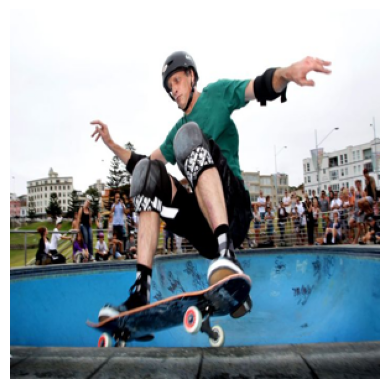

In [26]:
plt.axis("off")
plt.imshow(img)

In [27]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man on a skateboard jumping a ramp .
a man jumping a skateboard over a ramp .
a man is doing a trick on a skateboard .
a man on a skateboard performs a trick on a ramp .
a man on a skateboard is doing a trick .
a person jumping a skate board at the skate park
a man riding a skateboard down a ramp .
a man on a skateboard performs a trick in the air .
a man is doing a trick on a skateboard .
a skateboarder is doing a trick on a skateboard .


фотка с котиком и собачкой больше не загружается, не смогу нижнюю ячейку проверить(((

--2018-03-18 04:13:41--  http://ccanimalclinic.com/wp-content/uploads/2017/07/Cat-and-dog-1.jpg
Resolving ccanimalclinic.com (ccanimalclinic.com)... 64.207.177.234
Connecting to ccanimalclinic.com (ccanimalclinic.com)|64.207.177.234|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106870 (104K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 104,37K   194KB/s    in 0,5s    

2018-03-18 04:13:42 (194 KB/s) - ‘data/img.jpg’ saved [106870/106870]



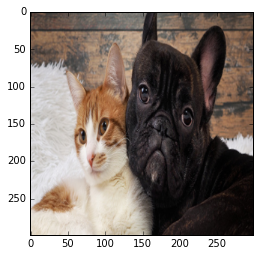

a cat laying down on a bed with a dog .
a cat laying on a bed with a laptop .
a cat laying on a bed with a dog .
a cat laying on a bed with a dog .
a cat laying on a bed in a bed .
a cat laying on a bed with a dog .
a cat laying on a bed with a dog .
a cat laying on a bed with a dog .
a cat laying on a bed with a dog .
a cat laying on a bed with a dog .


In [ ]:
# !wget http://ccanimalclinic.com/wp-content/uploads/2017/07/Cat-and-dog-1.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

### 5. Demo (2.5 балла)
##### **Найдите как минимум 10 изображений для теста.**

* Серьёзно, это часть задания — подготовьте хотя бы 10 картинок для генерации подписей.

* Сначала проверьте работу модели на простых изображениях, прежде чем переходить к более сложным.

* В вашем наборе должны быть примеры как удачных, так и неудачных подписей — проявите креативность :)

* Используйте фотографии, а не анимацию, 3D или рисунки — иначе придётся переобучать CNN на аниме.

* Обратите внимание на соотношение сторон изображений.

In [28]:
# apply your network on images you've found
#
#

def apply_network(file_path: str):
    img = Image.open(file_path)
    img = img.resize((299, 299))
    img = np.array(img).astype(np.float32) / 255.0
    plt.axis("off")
    plt.imshow(img)

    for i in range(10):
        print(' '.join(generate_caption(img, t=5.)[1:-1]))

a black cat laying on a green suitcase .
a black cat laying on a green suitcase .
a black cat laying on a blue blanket .
a black cat is sitting on a green suitcase .
a black cat laying on top of a white blanket .
a black cat laying on a green suitcase .
a black cat laying on top of a white sheet .
a black cat laying on top of a pile of luggage .
a black cat is laying on a green suitcase .
a black cat laying on a black suitcase


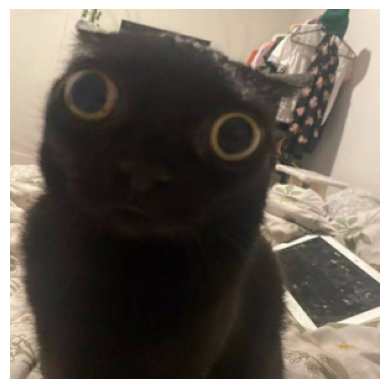

In [29]:
apply_network("data/test1.jpg")

тут ошибся с чемоданом

a car is parked on the street in a parking lot .
a car is parked on the side of a road .
a car is parked on the side of a road .
a car is parked on the side of a road .
a car is parked on the street next to a car .
a car sitting on a car in a parking lot .
a car is parked on a parking meter .
a car is parked on the side of a road .
a car is parked on the side of a road .
a car is parked on a parking lot .


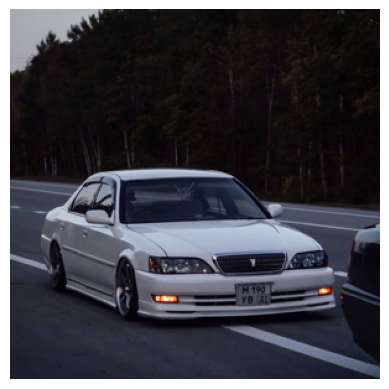

In [30]:
apply_network("data/test2.jpg")

тут ошибся: машина не припаркована всё же

a street light with a street sign and a building .
a street with traffic lights and a street light .
a street scene with a traffic light and a street sign .
a street with many cars and a street light .
a street scene with a traffic light and a street sign .
a street with a traffic light and a street sign .
a street scene with a traffic light and a street sign .
a traffic light on a city street with a traffic light .
a street with a traffic light and a street sign .
a street with a traffic light and a street sign .


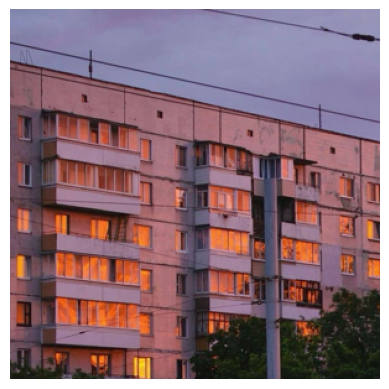

In [31]:
apply_network("data/test3.jpg")

жестко наошибался, тут нет светофора и знаков

a person riding a wave on a surfboard .
a person riding a wave on a surfboard .
a person riding a wave on a surfboard .
a man is surfing in the water .
a surfer is riding a wave in the ocean .
a person riding a wave on a surfboard .
a person riding a wave on a surfboard .
a person on a surf board in the water .
a surfer is riding a wave on a surfboard .
a person on a surf board in the water


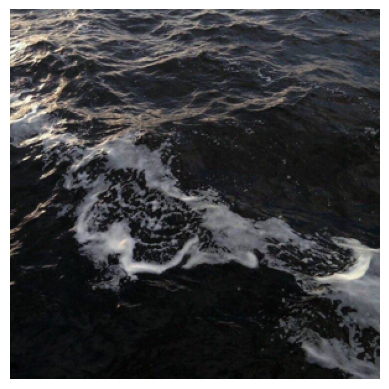

In [32]:
apply_network("data/test4.jpg")

тоже ошибся, тут нет человека

a large tower with a large clock tower .
a large building with a large clock tower .
a large tree with a large clock tower .
a large tree with a large clock tower .
a large tower with a clock on it
a large stone building with a clock on it
a large building with a clock tower in the background
a large building with a clock tower in the background
a large building with a clock tower in the background .
a large building with a clock on it


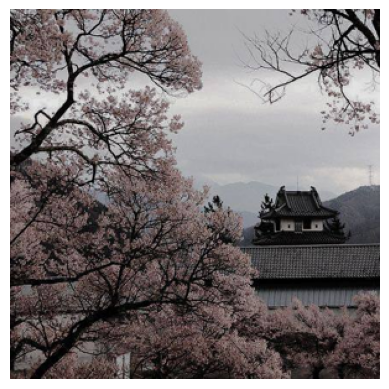

In [33]:
apply_network("data/test5.jpg")

нрмально

a laptop and a cell phone on a table .
a laptop and a cell phone sitting on a table .
a laptop computer sitting on a table with a keyboard .
a laptop and a cell phone sitting on a table .
a laptop computer sitting on a table with a keyboard .
a laptop and a cell phone sitting on a table .
a laptop computer on a table with a keyboard and mouse .
a laptop and a cell phone on a table
a laptop and a cell phone sitting on a table .
a laptop computer sitting on a table next to a keyboard .


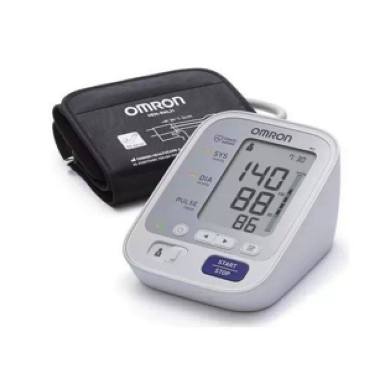

In [34]:
apply_network("data/test6.jpg")

увидел ноутбук, а изображён то тонометр)

a cat is sitting on a white plate .
a cat is sitting on a wooden table .
a cat is sitting on a table with a bowl of fruit .
a cat is laying on a white plate .
a cat is sitting on a table with a plate of food .
a cat is sitting on a table with a bowl of water .
a cat is sitting on a table with a plate of food .
a cat is sitting on a table with a plate of food .
a cat is sitting on a table with a bowl of food .
a cat is sitting on a table with a fork .


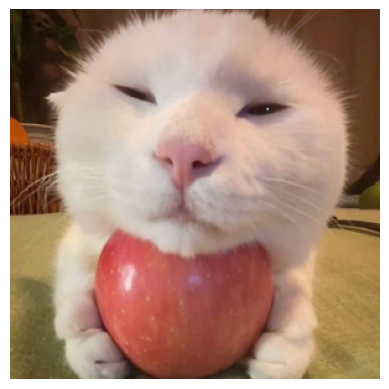

In [35]:
apply_network("data/test7.jpg")

кота нашёл, а яблочко не понял

a man holding a pink and white umbrella .
a man holding a pink umbrella and a girl .
a man holding a pink and white umbrella .
a man and woman standing next to a red fire hydrant .
a man holding a pink umbrella and a woman .
a man holding a pink umbrella and a white shirt .
a man holding a pink and white umbrella
a man and woman sitting on a bench .
a man holding a pink umbrella and a girl .
a man holding a pink umbrella in his hand .


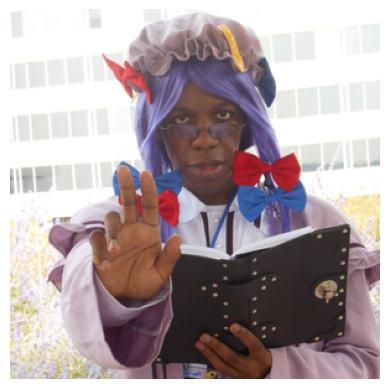

In [36]:
apply_network("data/test8.jpg")

не попал, хотя мужчину нашёл

a plate with a sandwich and a pickle
a plate with a sandwich and a pickle on it .
a plate with a sandwich and a pickle .
a plate with a sandwich and a pickle on it .
a hot dog with a pickle on it
a plate with a sandwich and a pickle on it
a hot dog with a bun and a pickle .
a hot dog with a sandwich and a pickle .
a plate of food with a sandwich and a pickle .
a plate of food with a sandwich and a fork .


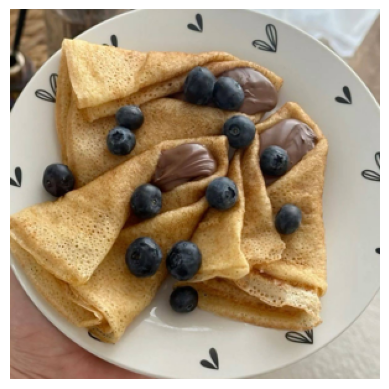

In [37]:
apply_network("data/test9.jpg")

блинчики тоже не угадал, но понял, что это еда

a man in a kitchen with a plate of food .
a man with a cake in his hand and a cup of coffee .
a man holding a piece of cake with a knife .
a man in a kitchen with a plate of food .
a man and a woman are standing in front of a laptop .
a man in a kitchen with a plate of food .
a man with a cake in his hand in a kitchen .
a man is cutting a cake with a knife .
a man with a cake in his hand and a cup of coffee .
a man with a hat and a knife in front of a laptop .


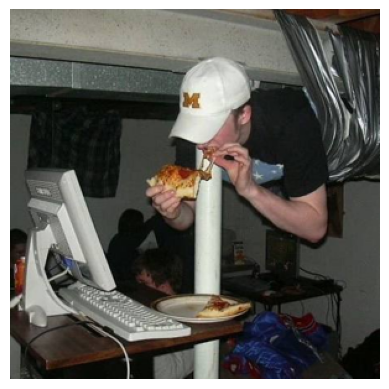

In [38]:
apply_network("data/test10.jpg")

последний caption конечно пугает, но в целом, в какой-то степени нормально


![img](https://cs7.pikabu.ru/images/big_size_comm_an/2018-09_3/1536865148163644198.gif)

> Примечание: Это задание адаптировано по материалам курса "Deep Learning" (Skoltech).


В целом модель понимает, что изображено на фото (человек, кот, еда), но ошибается в некоторых мелких деталях

Хотя в паре случаев несовпадение слишком сильное